# Интеллектуальный анализ данных – весна 2026
# Домашнее задание 6: классификация текстов

Правила:



*   Домашнее задание оценивается в 10 баллов.
*   Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.
*  Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.
*  Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.
*  Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе.
* Если в задании есть вопрос на рассуждение, то за отсутствие ответа на него балл за задание будет снижен вполовину.

В этом домашнем задании вам предстоит построить классификатор текстов.

Будем предсказывать эмоциональную окраску твиттов о коронавирусе.



In [36]:
import numpy as np
import pandas as pd
from typing import  List
import matplotlib.pyplot as plt
import seaborn as sns
from string import punctuation

In [37]:
df = pd.read_csv('/content/tweets_coronavirus.csv', encoding='latin-1')
df.sample(4)

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
13867,20628,65580,Parktown,23-03-2020,South Africa is food secure and consumers are ...,Negative
31871,43004,87956,NaN,12-04-2020,Hypothetically Had Cong been in power during t...,Extremely Negative
4692,9500,54452,NaN,19-03-2020,Please see this proposal:\r\r\nIf the whole co...,Positive
4473,9242,54194,NaN,19-03-2020,had 23 new confirmed cases yesterday so TW ppl...,Positive


Для каждого твитта указано:


*   UserName - имя пользователя, заменено на целое число для анонимности
*   ScreenName - отображающееся имя пользователя, заменено на целое число для анонимности
*   Location - местоположение
*   TweetAt - дата создания твитта
*   OriginalTweet - текст твитта
*   Sentiment - эмоциональная окраска твитта (целевая переменная)



## Задание 1 Подготовка (0.5 балла)

Целевая переменная находится в колонке `Sentiment`.  Преобразуйте ее таким образом, чтобы она стала бинарной: 1 - если у твитта положительная или очень положительная эмоциональная окраска и 0 - если отрицательная или очень отрицательная.

In [38]:
df['Sentiment'].unique()

array(['Positive', 'Extremely Negative', 'Negative', 'Extremely Positive'],
      dtype=object)

In [39]:
df['Sentiment'] = ((df['Sentiment'] ==  'Positive') | (df['Sentiment'] ==  'Extremely Positive')).astype(int)

In [40]:
df

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,1
1,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,1
2,3802,48754,NaN,16-03-2020,My food stock is not the only one which is emp...,1
3,3803,48755,NaN,16-03-2020,"Me, ready to go at supermarket during the #COV...",0
4,3804,48756,"ÃÂT: 36.319708,-82.363649",16-03-2020,As news of the regionÃÂs first confirmed COV...,1
...,...,...,...,...,...,...
33439,44949,89901,OHIO,14-04-2020,I never that weÃÂd be in a situation &amp; w...,1
33440,44950,89902,NaN,14-04-2020,@MrSilverScott you are definitely my man. I fe...,1
33441,44952,89904,NaN,14-04-2020,Response to complaint not provided citing COVI...,0
33442,44953,89905,NaN,14-04-2020,You know itÃÂs getting tough when @KameronWi...,1


Сбалансированы ли классы?

In [41]:
print(df['Sentiment'].sum(), len(df['Sentiment']) - df['Sentiment'].sum())

18046 15398


**Ответ:** Более-менее

Выведете на экран информацию о пропусках в данных. Если пропуски присутствуют заполните их строкой 'Unknown'.

In [42]:
df.isna().sum()

,0
UserName,0
ScreenName,0
Location,7049
TweetAt,0
OriginalTweet,0
Sentiment,0


In [43]:
df[df.isna()] = 'Unknown'

Разделите данные на обучающие и тестовые в соотношении 7 : 3 и укажите `random_state=0`

In [44]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, train_size=0.7, random_state=0)

## Задание 2 Токенизация (3 балла)

Постройте словарь на основе обучающей выборки и посчитайте количество встреч каждого токена с использованием самой простой токенизации - деления текстов по пробельным символам и приведения токенов в нижний регистр.

In [45]:
import warnings

import nltk
import pandas as pd
from nltk.tokenize import word_tokenize

warnings.filterwarnings("ignore")

In [46]:
slovar = pd.Series((' '.join(train['OriginalTweet'])).lower().split()).value_counts()

In [47]:
slovar

,count
the,26815
to,23373
and,14684
of,13012
a,11737
...,...
thc,1
telescope,1
amble,1
@srinivasiyc,1


Какой размер словаря получился?

In [48]:
len(slovar.keys())

79755

79755 уникальных слов

Выведите 10 самых популярных токенов с количеством встреч каждого из них. Объясните, почему именно эти токены в топе.

In [49]:
slovar.head(10)

,count
the,26815
to,23373
and,14684
of,13012
a,11737
in,11198
for,8566
#coronavirus,8223
is,7383
are,7050


**Ответ:** Это либо всякий мусор по типу союзов, предлогов и артиклей, но также есть и #coronovirus, что очень логично, так как он по идее должен быть в хэштегах почти у всех твитов

Удалите стоп-слова из словаря и выведите новый топ-10 токенов (и количество встреч) по популярности.  Что можно сказать  о нем?

In [50]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [51]:
import nltk
from nltk.corpus import stopwords

filtred_slovar = slovar[~slovar.index.isin(stopwords.words("english"))]

In [52]:
filtred_slovar.head(10)

,count
#coronavirus,8223
prices,3891
food,3820
grocery,3469
supermarket,3288
people,3175
covid-19,3173
store,3155
#covid19,2471
&amp;,2314


**Ответ:**  Ну теперь даже на правду похоже. Тут и обозначения коронавируса, и слова частоупотребимые и связанные с самоизоляцией. Единственное - амерсант сюда затесался - это непорядок

Также выведите 20 самых непопулярных слов (если самых непопулярных слов больше, выведите любые 20 из них) Почему эти токены непопулярны, требуется ли как-то дополнительно работать с ними?

In [53]:
filtred_slovar.tail(20)

,count
https://t.co/mrx9h61ffj,1
"idiot,",1
years'-supplies,1
https://t.co/8ts1ja4aac,1
renewing,1
playersãâ,1
subsidise,1
non-playing,1
premiership,1
https://t.co/wojgzo5bsz,1


**Ответ:** Ну опять какой-то мусор. Есть всего пара слов, которые реально такие редкие(renewing, subsidise и т. д.), но в основном - это связано с тем, что к слову припли знаки препинания или это вообще ссылка. Поэтому стоит лучше предобработать данные, чтобы не было таких недоразумений с прилипшими знаками



Теперь воспользуемся токенайзером получше - TweetTokenizer из библиотеки nltk. Примените его и посмотрите на топ-10 популярных слов. Чем он отличается от топа, который получался раньше? Почему?

In [54]:
from nltk.tokenize import TweetTokenizer

TweetSlovar = pd.Series(TweetTokenizer().tokenize(' '.join(train['OriginalTweet']))).str.lower().value_counts()

In [55]:
TweetSlovar.head(10)

,count
the,26993
.,24108
to,23478
",",17571
and,14825
of,13044
a,11891
in,11348
?,9524
#coronavirus,8808


**Ответ:** # Ну вообще только стоп слова и знаки препинания

Удалите из словаря стоп-слова и пунктуацию, посмотрите на новый топ-10 слов с количеством встреч, есть ли теперь в нем что-то не похожее на слова?

In [56]:
from string import punctuation

filtred_tweet_slovar = TweetSlovar[~(TweetSlovar.index.isin(stopwords.words("english")) | TweetSlovar.index.isin(set(punctuation)))]

In [57]:
filtred_tweet_slovar.head(10)

,count
#coronavirus,8808
â,7415
,7311
19,7167
covid,6253
prices,4601
,4372
food,4367
store,3877
supermarket,3805


**Ответ:** Какие-то кракозябры в топе, но наши прошлые слова всё ещё есть

Скорее всего в некоторых топах были неотображаемые символы или отдельные буквы не латинского алфавита. Уберем их: удалите из словаря токены из одного символа, позиция которого в таблице Unicode 128 и более (`ord(x) >= 128`)

Выведите топ-10 самых популярных и топ-20 непопулярных слов. Чем полученные топы отличаются от итоговых топов, полученных при использовании токенизации по пробелам? Что теперь лучше, а что хуже?

In [58]:
single_char = filtred_tweet_slovar.index[filtred_tweet_slovar.index.str.len() == 1]
bad_char = single_char[single_char.map(ord) >= 128]

filtred_filtred_tweet_slovar = filtred_tweet_slovar[~filtred_tweet_slovar.index.isin(bad_char)]

In [59]:
filtred_filtred_tweet_slovar.head(10)

,count
#coronavirus,8808
19,7167
covid,6253
prices,4601
food,4367
store,3877
supermarket,3805
grocery,3523
people,3463
#covid19,2589


In [60]:
filtred_filtred_tweet_slovar.tail(20)

,count
sao,1
suriname,1
post-brexit,1
plebs,1
@justglew,1
#storagetanks,1
#jetfuel,1
#budgets,1
https://t.co/d3tjbguydx,1
https://t.co/hjvwbtad1p,1


**Ответ:** очень похоже на предыдущий вариант, но теперь в топе есть циферки. Ну в конце списка убрались баганные слипшиеся слова и теперь там ссылочки и реально редкие слова

Выведите топ-10 популярных хештегов (токены, первые символы которых - #) с количеством встреч. Что можно сказать о них?

In [61]:
filtred_filtred_tweet_slovar[filtred_filtred_tweet_slovar.index.str.startswith('#')].head(10)

,count
#coronavirus,8808
#covid19,2589
#covid_19,1734
#covid2019,946
#toiletpaper,744
#covid,641
#socialdistancing,465
#coronacrisis,448
#pandemic,257
#coronaviruspandemic,249


**Ответ:** Почти всё - коронавирус. Но есть и паникёрская туалетная бумага. Ну и социальная дистанция

То же самое проделайте для ссылок на сайт https://t.co Сравнима ли популярность ссылок с популярностью хештегов? Будет ли информация о ссылке на конкретную страницу полезна?

In [62]:
filtred_filtred_tweet_slovar[filtred_filtred_tweet_slovar.index.str.startswith('https://t.co')].head(10)

,count
https://t.co/oxa7swtond,5
https://t.co/gp3eusapl8,4
https://t.co/deftrui1pfãâ,3
https://t.co/catkegayoy,3
https://t.co/3gbbdpdjat,3
https://t.co/e2znxajpre,3
https://t.co/oi39zsanq8,3
https://t.co/g63rp042ho,3
https://t.co/zjnrx6dkkn,3
https://t.co/wuieefsnoj,3


**Ответ:** Очень редкие эти ссылки, поэтому вряд ли конкретная ссыль будет иметь значения

Используем опыт предыдущих экспериментов и напишем собственный токенайзер, улучшив TweetTokenizer. Функция tokenize должна:



*   Привести текст в нижний регистр
*   Применить TweetTokenizer для  выделения токенов
*   Удалить стоп-слова, пунктуацию, токены из одного символа с позицией в таблице Unicode 128 и более,  ссылки на t.co



In [65]:
def custom_tokenizer(text):

  tokens = TweetTokenizer().tokenize(text.lower())
  punkt = set(punctuation)
  answer = []
  for t in tokens:
    if t not in stopwords.words("english") and t not in punkt and not (len(t) == 1 and ord(t) >= 128) and not t.startswith('https://t.co'):
      answer.append(t)

  return answer


In [66]:
custom_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext')

['sample', 'text', '@sample_text', '#sampletext']

## Задание 3 Векторизация текстов (2 балла)

Обучите CountVectorizer с использованием custom_tokenizer в качестве токенайзера. Как размер полученного словаря соотносится с размером изначального словаря из начала задания 2?

In [67]:
from sklearn.feature_extraction.text import CountVectorizer



cv = CountVectorizer(tokenizer=custom_tokenizer)
cv.fit(train['OriginalTweet'])

print(len(cv.vocabulary_))
print(len(slovar))

45290
79755


**Ответ:** Словарь получился почти в 2 раза меньше. Оно и понятно - тут мы очистили все багинные и лишние слова

Посмотрим на какой-нибудь конкретный твитт:

In [68]:
ind = 9023
train.iloc[ind]['OriginalTweet'], train.iloc[ind]['Sentiment']

('Nice one @SkyNews lets not panic but show ppl in france queueing for food!!! #CoronavirusOutbreak #COVID2019 brainless!! Ffs',
 np.int64(0))

Автор твитта не доволен ситуацией с едой во Франции и текст имеет резко негативную окраску.

Примените обученный CountVectorizer для векторизации данного текста, и попытайтесь определить самый важный токен и самый неважный токен (токен, компонента которого в векторе максимальна/минимальна, без учета 0). Хорошо ли они определились, почему?

In [71]:
vec = cv.transform([train.iloc[ind]['OriginalTweet']])

In [72]:
values = vec.toarray()[0][vec.toarray()[0] > 0]
names = cv.get_feature_names_out()[vec.toarray()[0] > 0]

print(values)
print(names)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1]
['#coronavirusoutbreak' '#covid2019' '@skynews' 'brainless' 'ffs' 'food'
 'france' 'lets' 'nice' 'one' 'panic' 'ppl' 'queueing' 'show']


**Ответ:** Все равнозначны, так как мы не учитываетаем значимость  слов, а только их вес

Теперь примените TfidfVectorizer и  определите самый важный/неважный токены. Хорошо ли определились, почему?

In [73]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vec = TfidfVectorizer(tokenizer=custom_tokenizer)
tfidf_vec.fit(train['OriginalTweet'])

TfidfVectorizer(tokenizer=<function custom_tokenizer at 0x7bc1ca949b20>)

In [74]:
vec = tfidf_vec.transform([train.iloc[ind]['OriginalTweet']])

In [75]:
values = vec.toarray()[0][vec.toarray()[0] > 0]
names = tfidf_vec.get_feature_names_out()[vec.toarray()[0] > 0]

print(values)
print(names)

[0.22584265 0.16825193 0.31042634 0.38676412 0.32447418 0.11328893
 0.32047314 0.3012107  0.25427292 0.16306723 0.1475947  0.25500646
 0.35434556 0.24406492]
['#coronavirusoutbreak' '#covid2019' '@skynews' 'brainless' 'ffs' 'food'
 'france' 'lets' 'nice' 'one' 'panic' 'ppl' 'queueing' 'show']


In [77]:
print(names[values.argmax()], values[values.argmax()])
print(names[values.argmin()], values[values.argmin()])

brainless 0.3867641170466375
food 0.11328893069250721


**Ответ:** Мне кажется, что получилось супер. brainless - редкое слово, означающие недовольность, а food - встречается часто и не несёт смысловой окраски

Найдите какой-нибудь положительно окрашенный твитт, где TfidfVectorizer хорошо (полезно для определения окраски) выделяет важный токен, поясните пример.

*Подсказка:* явно положительные твитты можно искать при помощи положительных слов (good, great, amazing и т. д.)

In [79]:
train[train['OriginalTweet'].apply(lambda x: 'awesome' in x) & (train['Sentiment'] == 1)]

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
663,4588,49540,954,17-03-2020,@HaileeSteinfeld IÃÂm good. Trying to keep m...,1
27905,38011,82963,"Bafoussam, Cameroon",08-04-2020,Get creative while in confinement This week we...,1
1640,5793,50745,Global,17-03-2020,A pianist in Barcelona went to his balcony dur...,1
28104,38260,83212,Unknown,08-04-2020,One of the top priorities Trump had when consi...,1
30507,41316,86268,Campbell River,10-04-2020,Let's be honest: #SocialDistancing sucks. Maki...,1
4139,8832,53784,Unknown,18-03-2020,@BoyersFood #COVID19 #WeAreInThisTogether \r\r...,1
17274,24818,69770,Unknown,25-03-2020,IF you can even FIND hand sanitizer the prices...,1
16392,23760,68712,"New Orleans, LA",24-03-2020,"Earlier this month, we completed Five Below in...",1
12783,19296,64248,"Essen, Germany",22-03-2020,its corona time Merch OUT NOW World wide shipp...,1
10890,17009,61961,"Wellington, FL, US, 33414",21-03-2020,Happy Saturday everyone!! We thought we'd ligh...,1


In [89]:
train.loc[20192]['OriginalTweet']

'Some awesome member of the public put this sign up a grocery store here in Adelaide South Australia  '

In [90]:
vec = tfidf_vec.transform([train.loc[20192]['OriginalTweet']])
values = vec.toarray()[0][vec.toarray()[0] > 0]
names = tfidf_vec.get_feature_names_out()[vec.toarray()[0] > 0]

print(values)
print(names)

[0.47474196 0.34007654 0.37845657 0.14761778 0.35809041 0.25182831
 0.26265217 0.31857648 0.33362806 0.14323609]
['adelaide' 'australia' 'awesome' 'grocery' 'member' 'public' 'put' 'sign'
 'south' 'store']


In [91]:
print(names[values.argmax()], values[values.argmax()])
print(names[values.argmin()], values[values.argmin()])

adelaide 0.4747419618244321
store 0.1432360925650737


**Ответ:** Короче здесь не повезло. В предложении редкое географическое место затесалось, поэтому оно на себя перетянуло одеяло. Но в принципе awesome топ2 по весу, поэто всё равно хорошо

## Задание 4 Обучение первых моделей (1 балл)

Примените оба векторайзера для получения матриц с признаками текстов.  Выделите целевую переменную.

In [92]:
X_train_cv = cv.transform(train['OriginalTweet'])
X_test_cv = cv.transform(test['OriginalTweet'])

X_train_tfidf = tfidf_vec.transform(train['OriginalTweet'])
X_test_tfidf = tfidf_vec.transform(test['OriginalTweet'])

y_train = train['Sentiment']
y_test = test['Sentiment']

Обучите логистическую регрессию на векторах из обоих векторайзеров. Посчитайте долю правильных ответов на обучающих и тестовых данных. Какой векторайзер показал лучший результат? Что можно сказать о моделях?

Используйте `sparse` матрицы (после векторизации), не превращайте их в `numpy.ndarray` или `pd.DataFrame` - может не хватить памяти.

In [93]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_cv = LogisticRegression()
lr_cv.fit(X_train_cv, y_train)

lr_tfidf = LogisticRegression()
lr_tfidf.fit(X_train_tfidf, y_train)



Train: 0.9846646732165741
Test:  0.8670520231213873


In [94]:
print("train:", accuracy_score(y_train, lr_cv.predict(X_train_cv)))
print("test: ", accuracy_score(y_test, lr_cv.predict(X_test_cv)))

Train: 0.9846646732165741
Test:  0.8670520231213873


In [95]:
print("train:", accuracy_score(y_train, lr_tfidf.predict(X_train_tfidf)))
print("test: ", accuracy_score(y_test, lr_tfidf.predict(X_test_tfidf)))

train: 0.9224263135412217
test:  0.85280047837353


**Ответ:** Обе модели получились отличные. Удивительно, что на более примитивном методе векторизации скор получился чуть больше. Также заметно, что в первом случае есть юольшой разрыв на тесте и трейне, а значит модель переобучилась

## Задание 5 Стемминг (0.5 балла)

Для уменьшения словаря можно использовать стемминг.

Модифицируйте написанный токенайзер, добавив в него стемминг с использованием SnowballStemmer. Обучите Count- и Tfidf- векторайзеры. Как изменился размер словаря?

In [108]:
print(custom_stem_tokenizer("This is a great day! #covid19 https://t.co/abc @user amazing"))
print(custom_tokenizer("This is a great day! #covid19 https://t.co/abc @user amazing"))

['great', 'day', '#covid19', '@user', 'amaz']
['great', 'day', '#covid19', '@user', 'amazing']


In [99]:
from nltk.stem.snowball import SnowballStemmer

def custom_stem_tokenizer(text):
  stemmer = SnowballStemmer("english")
  tokens = TweetTokenizer().tokenize(text.lower())
  punkt = set(punctuation)
  answer = []
  for t in tokens:
    if t not in stopwords.words("english") and t not in punkt and not (len(t) == 1 and ord(t) >= 128) and not t.startswith('https://t.co'):
      answer.append(stemmer.stem(t))

  return answer


In [ ]:
custom_stem_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext adding more words to check stemming')

['sampl', 'text', '@sample_text', '#sampletext', 'ad', 'word', 'check', 'stem']

In [100]:
custom_stem_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext adding more words to check stemming')

['sampl', 'text', '@sample_text', '#sampletext', 'ad', 'word', 'check', 'stem']

In [102]:
cv2 = CountVectorizer(tokenizer=custom_stem_tokenizer)

cv2.fit(train['OriginalTweet'])

print(len(cv2.vocabulary_))

36634


In [105]:
tfidf_vec2 = TfidfVectorizer(tokenizer=custom_stem_tokenizer)
tfidf_vec2.fit(train['OriginalTweet'])

TfidfVectorizer(tokenizer=<function custom_stem_tokenizer at 0x7bc1d553cae0>)

In [106]:
print(len(tfidf_vec2.vocabulary_))

36634


**Ответ** ну ещё 10к слов убралось - это логично, просто заменили однокоренные и всё

Обучите логистическую регрессию с использованием обоих векторайзеров. Изменилось ли качество? Есть ли смысл применять стемминг?

In [107]:
X_train_cv = cv2.transform(train['OriginalTweet'])
X_test_cv = cv2.transform(test['OriginalTweet'])

X_train_tfidf = tfidf_vec2.transform(train['OriginalTweet'])
X_test_tfidf = tfidf_vec2.transform(test['OriginalTweet'])

y_train = train['Sentiment']
y_test = test['Sentiment']

In [109]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_cv = LogisticRegression()
lr_cv.fit(X_train_cv, y_train)

lr_tfidf = LogisticRegression()
lr_tfidf.fit(X_train_tfidf, y_train)

LogisticRegression()

In [110]:
print("train:", accuracy_score(y_train, lr_cv.predict(X_train_cv)))
print("test: ", accuracy_score(y_test, lr_cv.predict(X_test_cv)))

train: 0.9720205040580948
test:  0.8674506677297189


In [111]:
print("train:", accuracy_score(y_train, lr_tfidf.predict(X_train_tfidf)))
print("test: ", accuracy_score(y_test, lr_tfidf.predict(X_test_tfidf)))

train: 0.9165741136266553
test:  0.8559896352401833


**Ответ:** Качество незначительно упало, поэтому здесь стемминг не сработал. Зато словарь уменьшился и по идее всё должно быть быстрее

## Задание  6 Работа с частотами (1.5 балла)

Еще один способ уменьшить количество признаков - это использовать параметры min_df и max_df при построении векторайзера  эти параметры помогают ограничить требуемую частоту встречаемости токена в документах.

По умолчанию берутся все токены, которые встретились хотя бы один раз.



Подберите max_df такой, что размер словаря будет 36651 (на 1 меньше, чем было). Почему параметр получился такой большой/маленький?

In [114]:
cv_df = CountVectorizer(tokenizer=custom_stem_tokenizer,
                        max_df=0.37
                        ).fit(
                            train['OriginalTweet']
                            )
print(len(cv_df.vocabulary_))

36633


**Ответ:** Это логично, все слова встречаются не в каждом предложении. А то что хештег присутствует больше, чем в трети сообщений - это уже большой успех

Подберите min_df (используйте дефолтное значение max_df) в CountVectorizer таким образом, чтобы размер словаря был 3700 токенов (при использовании токенайзера со стеммингом), а качество осталось таким же, как и было. Что можно сказать о результатах?

In [118]:
cv_df = CountVectorizer(tokenizer=custom_stem_tokenizer,
                        min_df = 11
                        ).fit(
                            train['OriginalTweet']
                            )
print(len(cv_df.vocabulary_))

3687


**Ответ:** Ну получается, что абсолютное большинство слов настолько редкие, что встречаются реже 11 раз. Поэтому на них тяжело обучиться и мы их дропаем

В предыдущих заданиях признаки не скалировались. Отскалируйте данные (при словаре размера 3.7 тысяч, векторизованные CountVectorizer), обучите логистическую регрессию, посмотрите качество и выведите `barplot`, содержащий по 10 токенов, с наибольшим по модулю положительными/отрицательными весами. Что можно сказать об этих токенах?

In [120]:
from sklearn.preprocessing import StandardScaler

X_train_df = cv_df.transform(train['OriginalTweet'])
X_test_df = cv_df.transform(test['OriginalTweet'])

scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train_df)
X_test_scaled = scaler.transform(X_test_df)

lr_scaled = LogisticRegression()
lr_scaled.fit(X_train_scaled, y_train)

print("train:", accuracy_score(y_train, lr_scaled.predict(X_train_scaled)))
print("test: ", accuracy_score(y_test, lr_scaled.predict(X_test_scaled)))

train: 0.9414780008543358
test:  0.8447279250548136


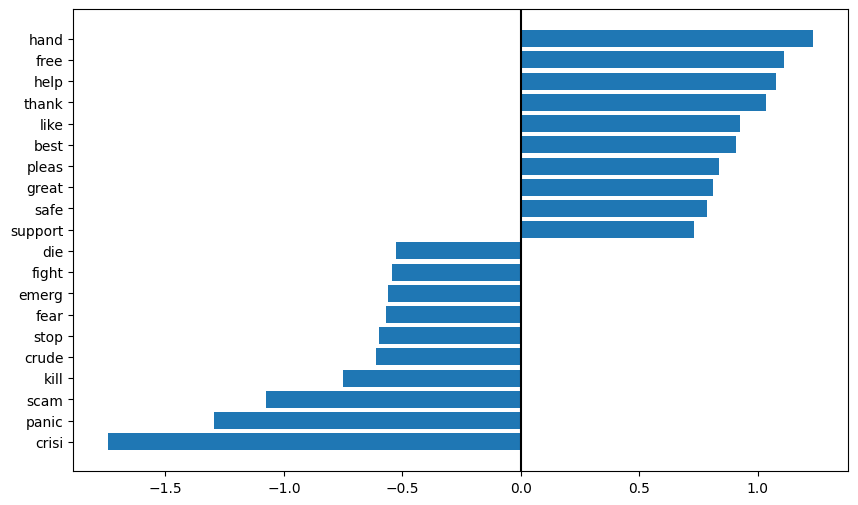

In [126]:
import matplotlib.pyplot as plt
import numpy as np

top_pos_idx = np.argsort(lr_scaled.coef_[0])[-10:]
top_neg_idx = np.argsort(lr_scaled.coef_[0])[:10]

names = cv_df.get_feature_names_out()[np.concatenate([top_neg_idx, top_pos_idx])]
values = lr_scaled.coef_[0][np.concatenate([top_neg_idx, top_pos_idx])]

plt.figure(figsize=(10, 6))
plt.barh(names, values)
plt.axvline(0, color='black')
plt.show()

In [122]:
top_pos_idx

array([3242, 2905, 1757, 2570,  776, 2120, 3317, 1829, 1651, 1792])

In [123]:
top_neg_idx

array([1163, 2480, 2931, 2042, 1170, 3185, 1560, 1409, 1577, 1275])

**Ответ:** Кстати, очень показательно получилось. Отрицательные отзывы содержат в себе упаднические и обвиняющие слова, а положительные - благодарные

## Задание 7 Другие признаки (1.5 балла)

Мы были сконцентрированы на работе с текстами твиттов и не использовали другие признаки - имена пользователя, дату и местоположение

Изучите признаки UserName и ScreenName. полезны ли они? Если полезны, то закодируйте их, добавьте к матрице с отскалированными признаками, обучите логистическую регрессию, замерьте качество.

In [132]:
print(train['UserName'].nunique(), train['UserName'].dtype)
print(train['ScreenName'].nunique(), train['ScreenName'].dtype)
print(len(train))

23410 int64
23410 int64
23410


**Ответ:** Они все уникальные, значит смело дропаем

Изучите признак TweetAt в обучающей выборке: преобразуйте его к типу datetime и нарисуйте его гистограмму с разделением по цвету на основе целевой переменной. Полезен ли он? Если полезен, то закодируйте его, добавьте к матрице с отскалированными признаками, обучите логистическую регрессию, замерьте качество.

<Axes: xlabel='TweetAt', ylabel='Count'>

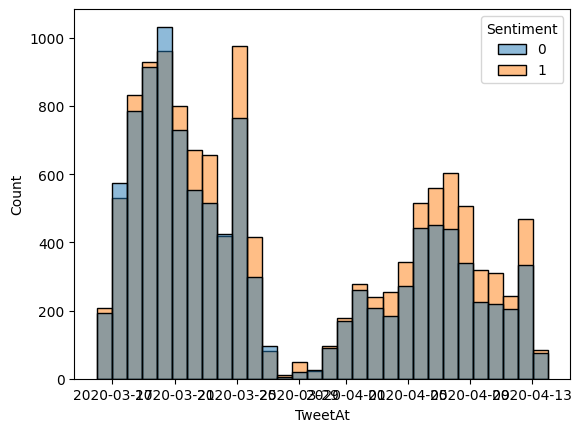

In [135]:
import seaborn as sns

train['TweetAt'] = pd.to_datetime(train['TweetAt'], format='%d-%m-%Y')

sns.histplot(data=train, x='TweetAt', hue='Sentiment', bins=30)


**Ответ:** Ничего здесь особенного нет, они точти одинаково распределены



Поработайте с признаком Location в обучающей выборке. Сколько уникальных значений?

In [136]:
print(train['Location'].nunique())

7949


Постройте гистограмму топ-10 по популярности местоположений (исключая Unknown)

<Axes: ylabel='Location'>

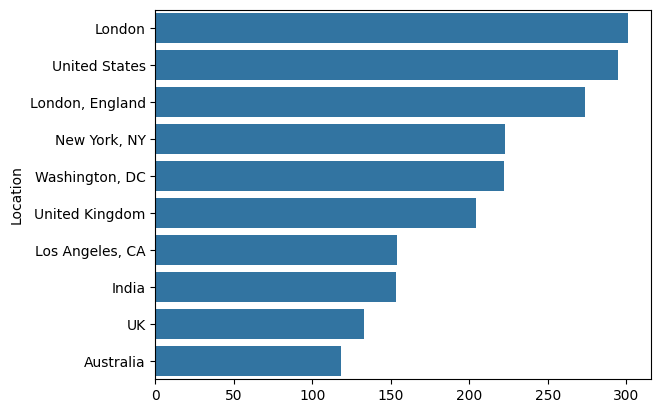

In [137]:
locations = train[train['Location'] != 'Unknown']['Location'].value_counts().head(10)

sns.barplot(x=locations.values, y=locations.index)

Видно, что многие местоположения включают в себя более точное название места, чем другие (Например, у некоторых стоит London, UK; а у некоторых просто UK или United Kingdom).

Создайте новый признак WiderLocation, который содержит самое широкое местоположение (например, из London, UK должно получиться UK). Сколько уникальных категорий теперь? Постройте аналогичную гистограмму.

4631


<Axes: ylabel='WiderLocation'>

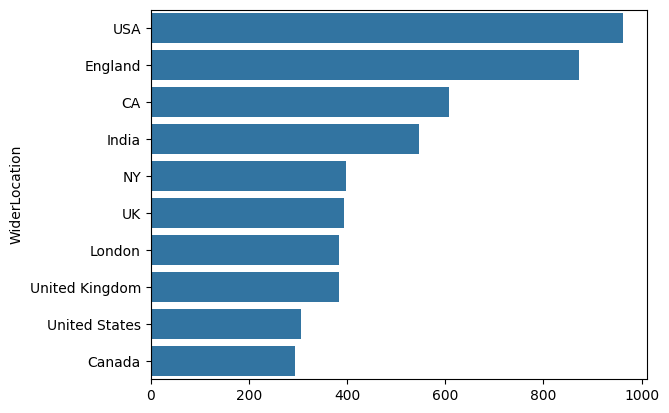

In [139]:
train['WiderLocation'] = train['Location'].str.split(',').str[-1].str.strip()
test['WiderLocation'] = test['Location'].str.split(',').str[-1].str.strip()

print(train['WiderLocation'].nunique())

wider = train[train['WiderLocation'] != 'Unknown']['WiderLocation'].value_counts().head(10)

sns.barplot(x=wider.values, y=wider.index)

Закодируйте признак WiderLocation с помощью OHE таким образом, чтобы создались только столбцы для местоположений, которые встречаются более одного раза. Сколько таких значений?


In [145]:
ohe = OneHotEncoder(min_frequency=2, handle_unknown='ignore', sparse_output=True,
                    categories=[train['WiderLocation'].unique()])

X_train_loc = ohe.fit_transform(train[['WiderLocation']])
X_test_loc = ohe.transform(test[['WiderLocation']])

print(X_train_loc.shape[1])

989


Добавьте этот признак к матрице отскалированных текстовых признаков, обучите логистическую регрессию, замерьте качество. Как оно изменилось? Оказался ли признак полезным?


*Подсказка:* используйте параметр `categories` в энкодере.

In [146]:
# -- YOUR CODE HERE --
X_train_combined = sp.hstack([X_train_scaled, X_train_loc])
X_test_combined = sp.hstack([X_test_scaled, X_test_loc])

lr_loc = LogisticRegression()
lr_loc.fit(X_train_combined, y_train)

print("train:", accuracy_score(y_train, lr_loc.predict(X_train_combined)))
print("test: ", accuracy_score(y_test, lr_loc.predict(X_test_combined)))

train: 0.9448099102947458
test:  0.8444289415985649


**Ответ:** Качество упало, получается локация тоже околобесполезна. Ну это и логично - люди из одной страны могут по разному относиться к действиям властей